<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>GraphRAG</h1>
<h1>1. Foundations: RAG, Graph RAG & Setup</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

**A hands-on Graph RAG workshop** · spaCy → fastcoref → REBEL → NetworkX → LLM

This workshop is split into four notebooks, one per agenda section:

| Notebook | Covers | Reads checkpoint | Writes checkpoint |
|---|---|---|---|
| **Part 1 (this one)** | RAG fundamentals, Graph RAG architecture, environment setup, corpus | — | `corpus.txt` |
| Part 2 | Stages 1–3: spaCy → fastcoref → REBEL | `corpus.txt` | `entities.jsonl`, `resolved.txt`, `triples.jsonl` |
| Part 3 | Stage 4: build, query & analyze the NetworkX graph | `triples.jsonl` | `graph.graphml` |
| Part 4 | Chatbot, evaluation, production | `triples.jsonl`, `resolved.txt` | — |

## The checkpoint system

Each part ends by **saving its outputs** to a shared `checkpoints/` folder, and each part begins by **loading what it needs** from there. If a checkpoint is missing — you skipped a part, or a model failed to download on your machine — the notebook **falls back to built-in data and keeps going**. Every part runs end to end, alone or in sequence. (This is standard workshop hygiene: one broken stage should never strand you.)

## What we're building, in one picture

```
                       OFFLINE (index time)
 raw text ─► spaCy ─► fastcoref ─► REBEL ─► triples ─► NetworkX graph
  Part 1     Part 2     Part 2      Part 2    Part 2       Part 3
                                                              │
                       ONLINE (query time)                    ▼
 question ─► entity linking ─► graph traversal ─► facts ─► LLM ─► grounded answer
                                    Part 4
```

**Requirements:** a laptop with basic Python. No NLP background needed.

---
## 1.1 Environment setup

We install the full workshop stack **once, here** — Parts 2–4 re-check only what they need. The table maps each package to its job:

| Package | Role |
|---|---|
| `spacy` (+ `en_core_web_sm`) | Stage 1: sentence segmentation & named-entity recognition |
| `fastcoref` | Stage 2: coreference resolution (pronouns → entities) |
| `transformers` + `torch` | Stage 3: runs the REBEL triple-extraction model |
| `networkx` | Stage 4: the in-memory graph |
| `datasets` | loads the wikitext-103 corpus |
| `scikit-learn` | a tiny TF-IDF retriever — our **vector-RAG baseline** to beat |
| `matplotlib` | graph visualization |
| `anthropic` | *(optional)* the LLM for the chatbot's generation step |

Everything runs **in-process** — no database server, no Docker.

In [1]:
import importlib
import json
import sys
from pathlib import Path

import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from datasets import load_dataset

import matplotlib.pyplot as plt 

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.15.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 9f7b8f641170ae4066def95c2266e8f9ada7bc64

datasets  : 5.0.0
json      : 2.0.9
matplotlib: 3.11.0
sklearn   : 1.9.0
torch     : 2.12.1
watermark : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

And detect what hardware we're working with

In [4]:
if torch.cuda.is_available():
    DEVICE = "cuda"          # NVIDIA GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"           # Apple Silicon GPU
else:
    DEVICE = "cpu"
    
print(f"models will run on: {DEVICE}")

models will run on: mps


In [5]:
# --- Checkpoint system ----------------------------------------------------------
# Every part of this workshop READS its inputs from, and WRITES its outputs to,
# a shared `checkpoints/` directory next to the notebooks. If an expected
# checkpoint is missing (you skipped a part, or a stage failed on your machine),
# we fall back to built-in data so THIS notebook still runs end to end.
# That mirrors good workshop practice: nobody gets stranded because an earlier
# stage broke — you load the checkpoint and keep moving.
CKPT = Path("checkpoints")
CKPT.mkdir(exist_ok=True)

def save_text(name, text):
    (CKPT / name).write_text(text, encoding="utf-8")
    print(f"[checkpoint] saved  {CKPT / name}  ({len(text):,} chars)")

def load_text(name, fallback=None):
    p = CKPT / name
    if p.exists():
        print(f"[checkpoint] loaded {p}")
        return p.read_text(encoding="utf-8")
    print(f"[checkpoint] {p} NOT FOUND — using built-in fallback data")
    return fallback

def save_jsonl(name, rows):
    with open(CKPT / name, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
    print(f"[checkpoint] saved  {CKPT / name}  ({len(rows)} rows)")

def load_jsonl(name, fallback=None):
    p = CKPT / name
    if p.exists():
        rows = [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]
        print(f"[checkpoint] loaded {p}  ({len(rows)} rows)")
        return rows
    print(f"[checkpoint] {p} NOT FOUND — using built-in fallback data")
    return fallback

---
## 1.2 RAG fundamentals (and where vector RAG breaks)

### Why ground an LLM at all?

Large language models generate text from patterns learned during training. That gives them three well-known failure modes:

1. **Hallucination** — fluent, confident, *wrong* statements.
2. **Staleness** — nothing after the training cutoff exists.
3. **Blindness to your data** — your documents, tickets, and conversations were never in the training set.

**Retrieval-Augmented Generation (RAG)** addresses all three with one idea: *before* the model answers, retrieve relevant source material and hand it over as context. The model's job shifts from "recall facts" to "read these facts and compose an answer" — a much safer job.

### The classic (vector) RAG loop

```
documents ─► chunk ─► embed ─► vector index
                                    ▲
question ─► embed ─► nearest-neighbor search ─► top-k chunks ─► LLM ─► answer
```

Text is split into **chunks**, each chunk becomes an **embedding** (a vector capturing its meaning), and at question time we fetch the chunks whose vectors sit *closest* to the question's vector.

### Where it breaks — the motivation for graphs

Vector similarity retrieves chunks that **sound like the question**. That fails when the answer depends on **relationships between facts**, not on any single similar-sounding passage:

- **Multi-hop questions**: *"What field did Marie Curie's husband work in?"* — no single chunk contains the answer; it must be *composed* across facts.
- **Global questions**: *"Which people are connected to both organization A and city B?"* — that's a *join*, and joins are what similarity search fundamentally cannot do.
- **Relationship-first questions**: *"How is X related to Y?"* — the relationship IS the answer.

Let's make that concrete with a deliberately simple baseline — we'll meet it again in Part 4 (Evaluation), where the graph has to beat it.

> **An honest simplification:** we use **TF-IDF** (word overlap) instead of neural embeddings, keeping the baseline dependency-light and instant. TF-IDF is cruder, but it fails multi-hop questions *for the same structural reason* embeddings do: both retrieve individual chunks by similarity to the question, and neither can compose facts across chunks. The structural failure — not the similarity function — is the lesson.

In [6]:
# --- A minimal "vector-style" retrieval baseline ----------------------------
class ChunkRetriever:
    """Similarity-based chunk retrieval: the skeleton of vector RAG."""

    def __init__(self, chunks):
        self.chunks = chunks
        # Fit TF-IDF: every chunk becomes a sparse vector of word weights.
        self.vectorizer = TfidfVectorizer(stop_words="english")
        self.matrix = self.vectorizer.fit_transform(chunks)

    def retrieve(self, question, k=2):
        # Embed the question in the same space; rank chunks by cosine similarity.
        q_vec = self.vectorizer.transform([question])
        scores = cosine_similarity(q_vec, self.matrix)[0]
        ranked = scores.argsort()[::-1][:k]
        return [(self.chunks[i], float(scores[i])) for i in ranked]

# A toy corpus with facts spread ACROSS chunks — on purpose.
toy_chunks = [
    "Marie Curie was a physicist and chemist who conducted pioneering research on radioactivity.",
    "Marie Curie was born in Warsaw, in what was then the Kingdom of Poland.",
    "Pierre Curie was a French physicist and a pioneer in crystallography and magnetism.",
    "Marie Curie married Pierre Curie in 1895 in Sceaux, France.",
    "The Curie Institute in Paris was founded in 1920 and remains a major cancer research center.",
]

toy_baseline = ChunkRetriever(toy_chunks)

# A single-fact question: vector-style retrieval handles this well.
for chunk, score in toy_baseline.retrieve("Where was Marie Curie born?", k=2):
    print(f"[{score:.2f}] {chunk}")

[0.60] Marie Curie was born in Warsaw, in what was then the Kingdom of Poland.
[0.28] Marie Curie married Pierre Curie in 1895 in Sceaux, France.


In [10]:
# Now a MULTI-HOP question. Answering requires composing two chunks:
#   hop 1: Marie Curie married Pierre Curie
#   hop 2: Pierre Curie was a French physicist
for chunk, score in toy_baseline.retrieve(
        "What field did Marie Curie's husband work in?", k=2):
    print(f"[{score:.2f}] {chunk}")

# Typical result: chunks mentioning "Marie Curie" rank highest because the
# question SOUNDS like them — but the chunk holding the answer (Pierre's field)
# may not surface, because the question never says "Pierre". The retriever
# cannot follow the 'married' link. A graph can. That's the whole pitch.

[0.45] Marie Curie married Pierre Curie in 1895 in Sceaux, France.
[0.38] Marie Curie was born in Warsaw, in what was then the Kingdom of Poland.


---
## 1.3 Graph RAG architecture

**Graph RAG** reframes retrieval. Instead of treating documents as bags of opaque chunks, we *extract the facts themselves* — as **(head, relation, tail)** triples — and store them in a graph:

```
("Marie Curie",  "spouse",         "Pierre Curie")
("Pierre Curie", "field of work",  "physics")
("Marie Curie",  "place of birth", "Warsaw")
```

Nodes are **entities**; edges are **typed relationships**. The multi-hop question above becomes a two-edge *traversal* — trivial for a graph, impossible for chunk similarity:

```
Marie Curie ──spouse──► Pierre Curie ──field of work──► physics
```

### Two phases, like vector RAG — different index

- **Offline (index time):** text → entities → resolved references → triples → graph. (Parts 2 & 3.)
- **Online (query time):** question → entity linking → traversal → facts → LLM → grounded answer. (Part 4.)

### Where this sits in the wider landscape

- **Hybrid systems** combine both: vectors for fuzzy recall of passages, graphs for precise relational facts. Production systems often run both.
- **Microsoft's GraphRAG** popularized LLM-built graphs plus community summarization for "global" questions over a corpus.
- **Agent memory** is the emerging frontier: a graph gives an agent *durable, queryable, inspectable* memory — you can audit exactly what the agent "knows" and why, which an embedding index can't offer.

Our version is deliberately minimal — classical NLP models rather than LLM extraction, NetworkX rather than a graph database — so every moving part is visible and cheap to run. The *shape* of the system is the lesson; every component has an industrial-strength replacement.

---
## 1.4 The corpus

We use **wikitext-103-v1**: clean, well-structured Wikipedia articles, small enough to process live. The recipe transfers unchanged to your own documents, support tickets, or agent conversation history.

Practical notes:

- The dataset is a stream of *lines*, with headings marked like `= Title =`. We reassemble contiguous prose, skipping headings. By default we load the **full train split**; pass `target_chars` to `load_wikitext()` if you want a smaller slice for quick experiments.
- **Cached on disk.** The first run downloads the dataset once; the `datasets` library caches it locally (`~/.cache/huggingface/datasets`), so every later run loads straight from disk — no re-download.
- **Offline fallback:** if the download fails, we use a built-in sample text (a pronoun-rich Marie Curie paragraph — chosen because it makes Part 2's coreference demo vivid) so everything downstream still runs.
- **Mind the runtime downstream.** REBEL on CPU costs roughly ~1s per sentence, so the full corpus takes a long time in Part 2 — use `load_wikitext(target_chars=4000)` while validating the pipeline, then scale up.

In [11]:
FALLBACK_TEXT = (
    "Marie Curie was a Polish and naturalised-French physicist and chemist. She conducted pioneering research on radioactivity. She was the first woman to win a Nobel Prize, and she remains the only person to win Nobel Prizes in two scientific fields. Marie Curie was born in Warsaw. She studied at the University of Paris, where she met Pierre Curie. Pierre Curie was a French physicist. He shared the 1903 Nobel Prize in Physics with Marie Curie and Henri Becquerel. Marie Curie married Pierre Curie in 1895. After Pierre died in 1906, Marie Curie took over his professorship at the University of Paris. She became the first woman to teach at the university. Marie Curie founded the Curie Institute in Paris in 1920. It remains a major centre for medical research today. Her daughter Irene Joliot-Curie was also a chemist. Irene Joliot-Curie won the Nobel Prize in Chemistry in 1935 with her husband Frederic Joliot-Curie."
)

def load_wikitext(target_chars=None):
    """Return contiguous article prose from wikitext-103.

    The dataset is downloaded ONCE and cached on disk by the `datasets`
    library (default: ~/.cache/huggingface/datasets). Subsequent runs load
    straight from the local cache — no re-download.

    By default the FULL train split is returned. Pass `target_chars` to keep
    only the first ~target_chars of prose (handy for quick experiments).
    """
    ds = load_dataset("Salesforce/wikitext", "wikitext-103-v1", split="train")
    parts, total = [], 0
    for line in ds["text"]:
        line = line.strip()
        if not line or line.startswith("="):      # skip blanks and headings
            continue
        parts.append(line)
        total += len(line)
        if target_chars is not None and total >= target_chars:
            break
    return " ".join(parts)

try:
    raw_text = load_wikitext()
    source = "wikitext-103-v1"
except Exception as e:                             # no network, HF hiccup, etc.
    print(f"Dataset load failed ({type(e).__name__}) — using fallback text.")
    raw_text = FALLBACK_TEXT
    source = "built-in fallback"

print(f"Corpus source: {source} · {len(raw_text):,} characters")
print("\nFirst 400 characters:\n" + raw_text[:400] + " …")

Corpus source: wikitext-103-v1 · 526,514,281 characters

First 400 characters:
Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical an …


> **Tip:** for a quick run, load a small slice with `raw_text = load_wikitext(target_chars=4000)`, or use the fallback text by setting `raw_text = FALLBACK_TEXT` before saving the checkpoint below.

---
## 1.5 Exploratory data analysis

Before pushing text through a four-stage NLP pipeline, we should know what that text actually looks like. Every downstream decision — chunk sizes, model runtime, extraction quality — depends on properties we can measure right now, in seconds:

- **Size & structure** — how much text, organized into how many articles?
- **Word distributions** — does the corpus follow Zipf's law? What's the working vocabulary?
- **Sentence lengths** — REBEL (Part 2) processes one sentence at a time at ~1s/sentence on CPU, so the sentence count *is* the runtime budget.
- **Tokenization quirks** — wikitext ships pre-tokenized with artifacts (`<unk>`, `@-@`) that will show up inside extracted entities if we're not aware of them.
- **Entity preview** — a crude look at what named entities Part 2's NER stage is likely to find.

> **A note on sampling:** cheap global counts use the full corpus; distribution statistics run on a capped sample (first ~10M characters) so this section stays fast even when the full ~500MB train split is loaded.

In [12]:
import re
from collections import Counter

import numpy as np

# Heavy string analyses run on a capped sample so this section stays fast
# even with the full train split loaded. Global counts use everything.
EDA_MAX_CHARS = 10_000_000
eda_text = raw_text[:EDA_MAX_CHARS]
if len(raw_text) > len(eda_text):
    print(f"(distribution stats use the first {len(eda_text):,} of {len(raw_text):,} chars)\n")

tokens = eda_text.split()
words  = [t.lower() for t in tokens if t.isalpha()]
vocab  = set(words)
# wikitext is pre-tokenized, so sentence-final punctuation is always followed
# by whitespace — a regex split is good enough for corpus statistics.
sentences = [s for s in re.split(r"(?<=[.!?])\s+", eda_text) if s.strip()]

print(f"characters (full corpus)   : {len(raw_text):>12,}")
print(f"tokens (sample)            : {len(tokens):>12,}")
print(f"alphabetic words (sample)  : {len(words):>12,}")
print(f"unique words / vocabulary  : {len(vocab):>12,}")
print(f"type-token ratio           : {len(vocab) / len(words):>12.4f}")
print(f"mean word length           : {sum(map(len, words)) / len(words):>12.2f} chars")
print(f"sentences (sample)         : {len(sentences):>12,}")
print(f"mean sentence length       : {len(tokens) / len(sentences):>12.1f} tokens")

(distribution stats use the first 10,000,000 of 526,514,281 chars)

characters (full corpus)   :  526,514,281
tokens (sample)            :    1,884,935
alphabetic words (sample)  :    1,541,386
unique words / vocabulary  :       52,800
type-token ratio           :       0.0343
mean word length           :         4.91 chars
sentences (sample)         :       73,852
mean sentence length       :         25.5 tokens


### Article structure

Wikitext-103 is ~28k full Wikipedia articles. In the raw line stream, top-level headings look like `= Title =` and subsections like `= = Section = =`. Counting them tells us how the corpus is organized — and the distribution of article lengths tells us whether our prose slice is dominated by a few giant articles or spread across many small ones. (This cell reads the dataset again, but it comes straight from the local cache — no download.)

articles              : 29,444
sub-section headings  : 276,053
chars per article     : median 13,238 · mean 17,853 · max 141,406


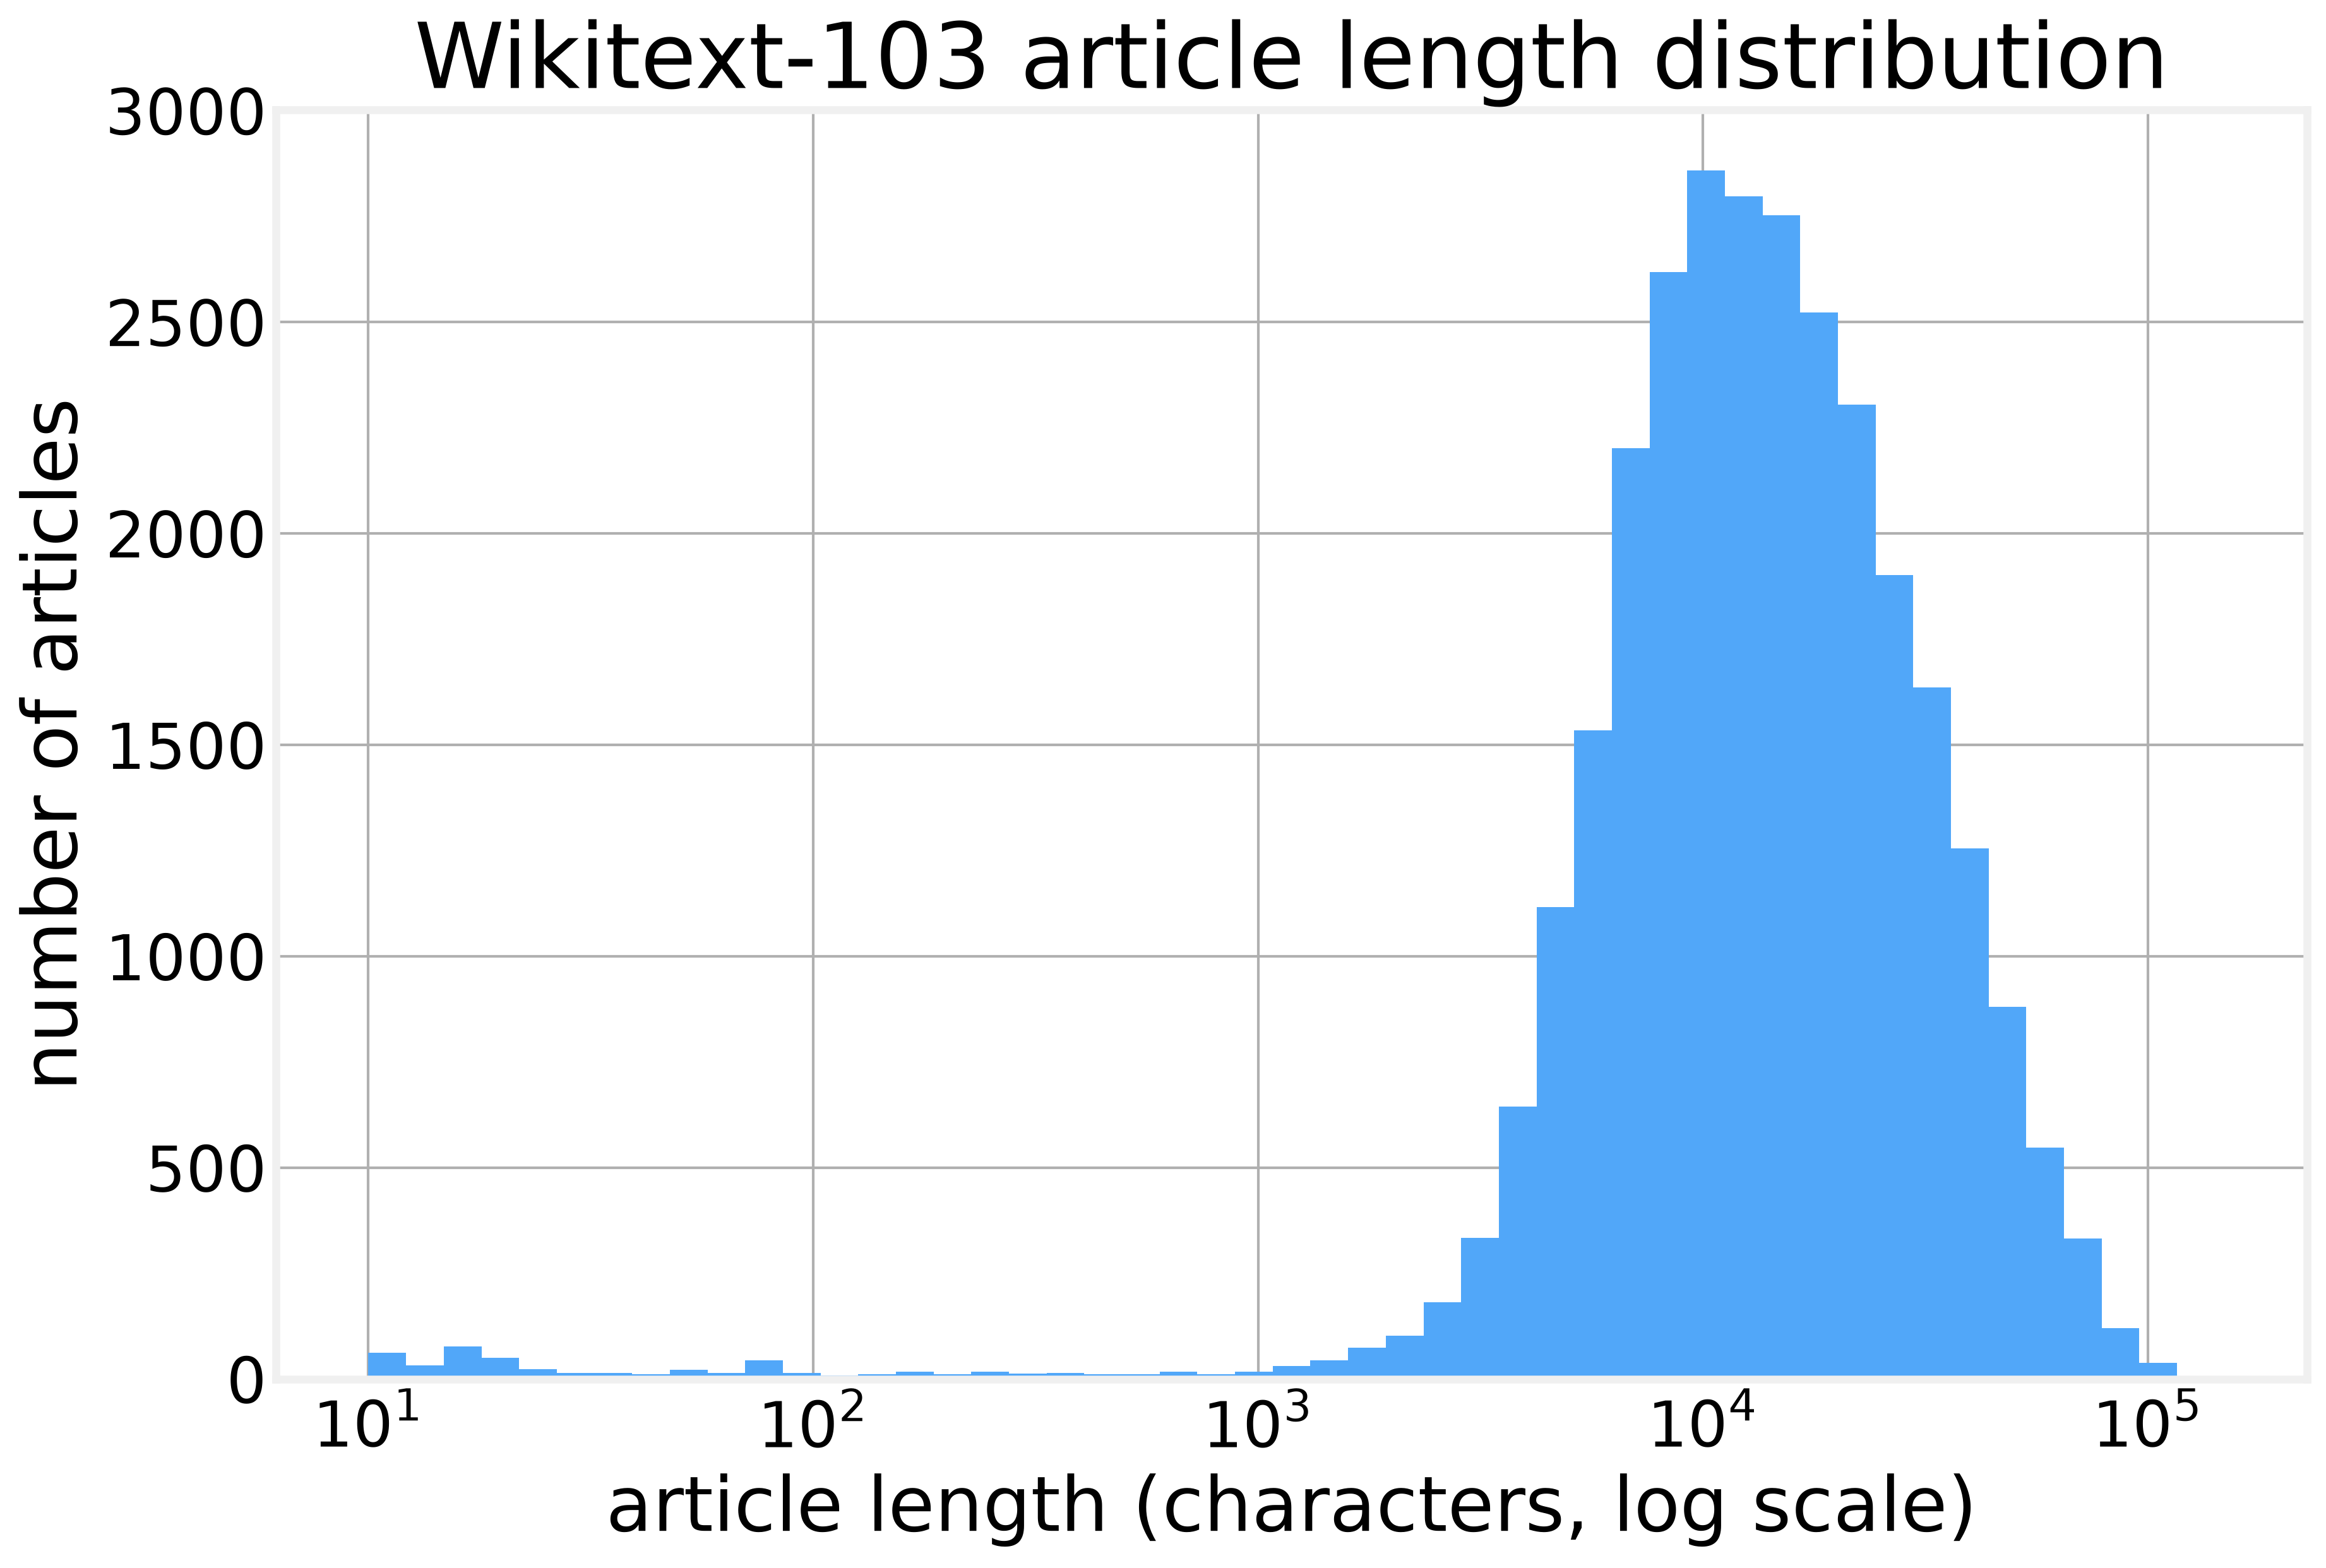

In [13]:
if source == "wikitext-103-v1":
    ds = load_dataset("Salesforce/wikitext", "wikitext-103-v1", split="train")

    article_lens, current, n_sections = [], 0, 0
    for line in ds["text"]:
        stripped = line.strip()
        if re.fullmatch(r"= [^=].* =", stripped):     # top-level heading → new article
            if current:
                article_lens.append(current)
            current = 0
        elif stripped.startswith("="):                # sub-section heading
            n_sections += 1
        else:                                         # prose (or blank)
            current += len(stripped)
    if current:
        article_lens.append(current)
    article_lens = np.array(article_lens)

    print(f"articles              : {len(article_lens):,}")
    print(f"sub-section headings  : {n_sections:,}")
    print(f"chars per article     : median {np.median(article_lens):,.0f} · "
          f"mean {article_lens.mean():,.0f} · max {article_lens.max():,.0f}")

    fig, ax = plt.subplots()
    bins = np.logspace(np.log10(max(article_lens.min(), 10)),
                       np.log10(article_lens.max()), 50)
    ax.hist(article_lens, bins=bins, color=colors[0])
    ax.set_xscale("log")
    ax.set_xlabel("article length (characters, log scale)")
    ax.set_ylabel("number of articles")
    ax.set_title("Wikitext-103 article length distribution")
    plt.tight_layout()
else:
    print("Using the built-in fallback text — no article structure to analyze.")

### Word frequencies and Zipf's law

Two views of the same `Counter`:

- **Left** — the most frequent *content* words (stopwords removed). These are the concepts the corpus is actually about, and a preview of the vocabulary our knowledge graph will be built from.
- **Right** — the full rank-frequency plot on log-log axes. Natural language famously follows **Zipf's law**: frequency ∝ 1/rank, a straight line with slope ≈ −1. A handful of words do most of the work while the vast majority appear only a few times — which is exactly why TF-IDF (our Part 4 baseline) down-weights the common words.

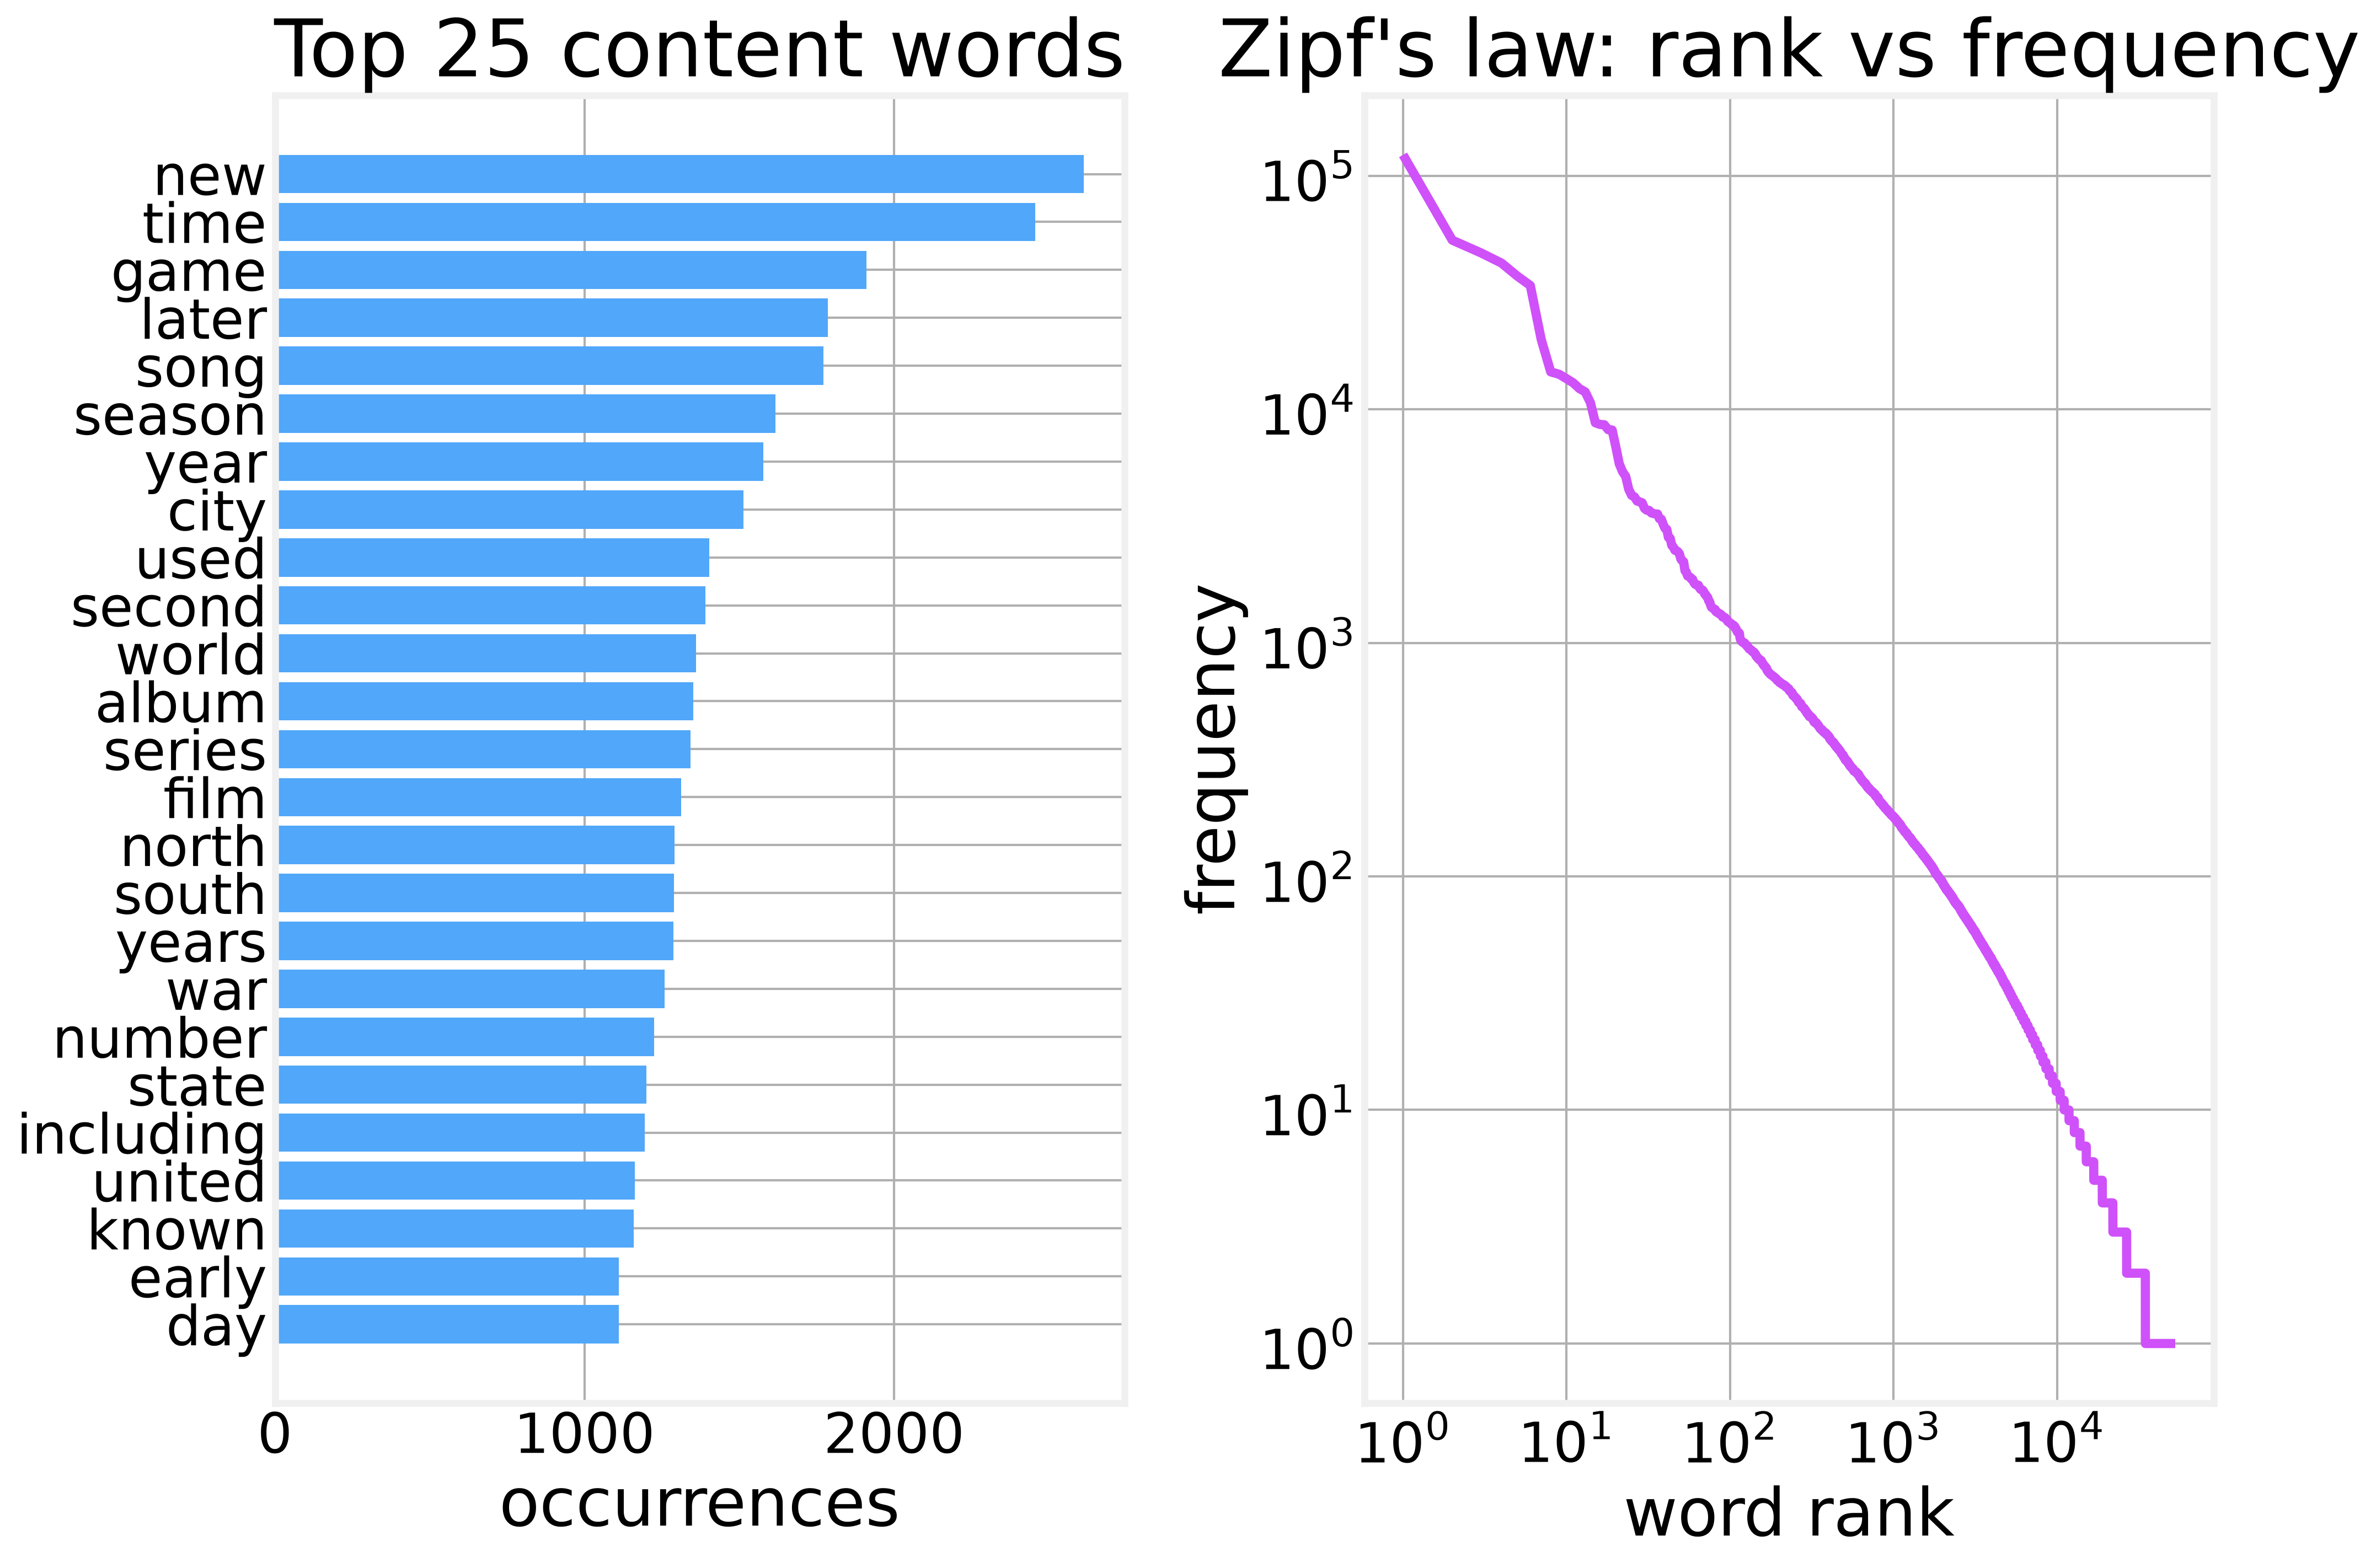

In [14]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

freq = Counter(words)
content_words = [(w, c) for w, c in freq.most_common(500)
                 if w not in ENGLISH_STOP_WORDS][:25]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))

labels, counts = zip(*content_words)
ax1.barh(range(len(labels)), counts, color=colors[0])
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels)
ax1.invert_yaxis()
ax1.set_xlabel("occurrences")
ax1.set_title("Top 25 content words")

ranked = np.array(sorted(freq.values(), reverse=True))
ax2.loglog(np.arange(1, len(ranked) + 1), ranked, color=colors[1])
ax2.set_xlabel("word rank")
ax2.set_ylabel("frequency")
ax2.set_title("Zipf's law: rank vs frequency")

plt.tight_layout()

### Sentence lengths — the Part 2 runtime budget

REBEL extracts triples **one sentence at a time**, at roughly **~1 second per sentence on CPU** (much faster on GPU). So the sentence count of whatever we freeze into `corpus.txt` directly sets how long Part 2 takes. Sentence *length* matters too: very long sentences get truncated by the model's input window, and very short ones rarely contain a complete (head, relation, tail) fact.

sentences (sample)   : 73,852
tokens per sentence  : median 24 · mean 25.5 · p95 49

estimated sentences in full corpus : 3,888,413
estimated REBEL time on CPU        : ~1,080.1 hours (~1 s/sentence — use target_chars for a quick run!)


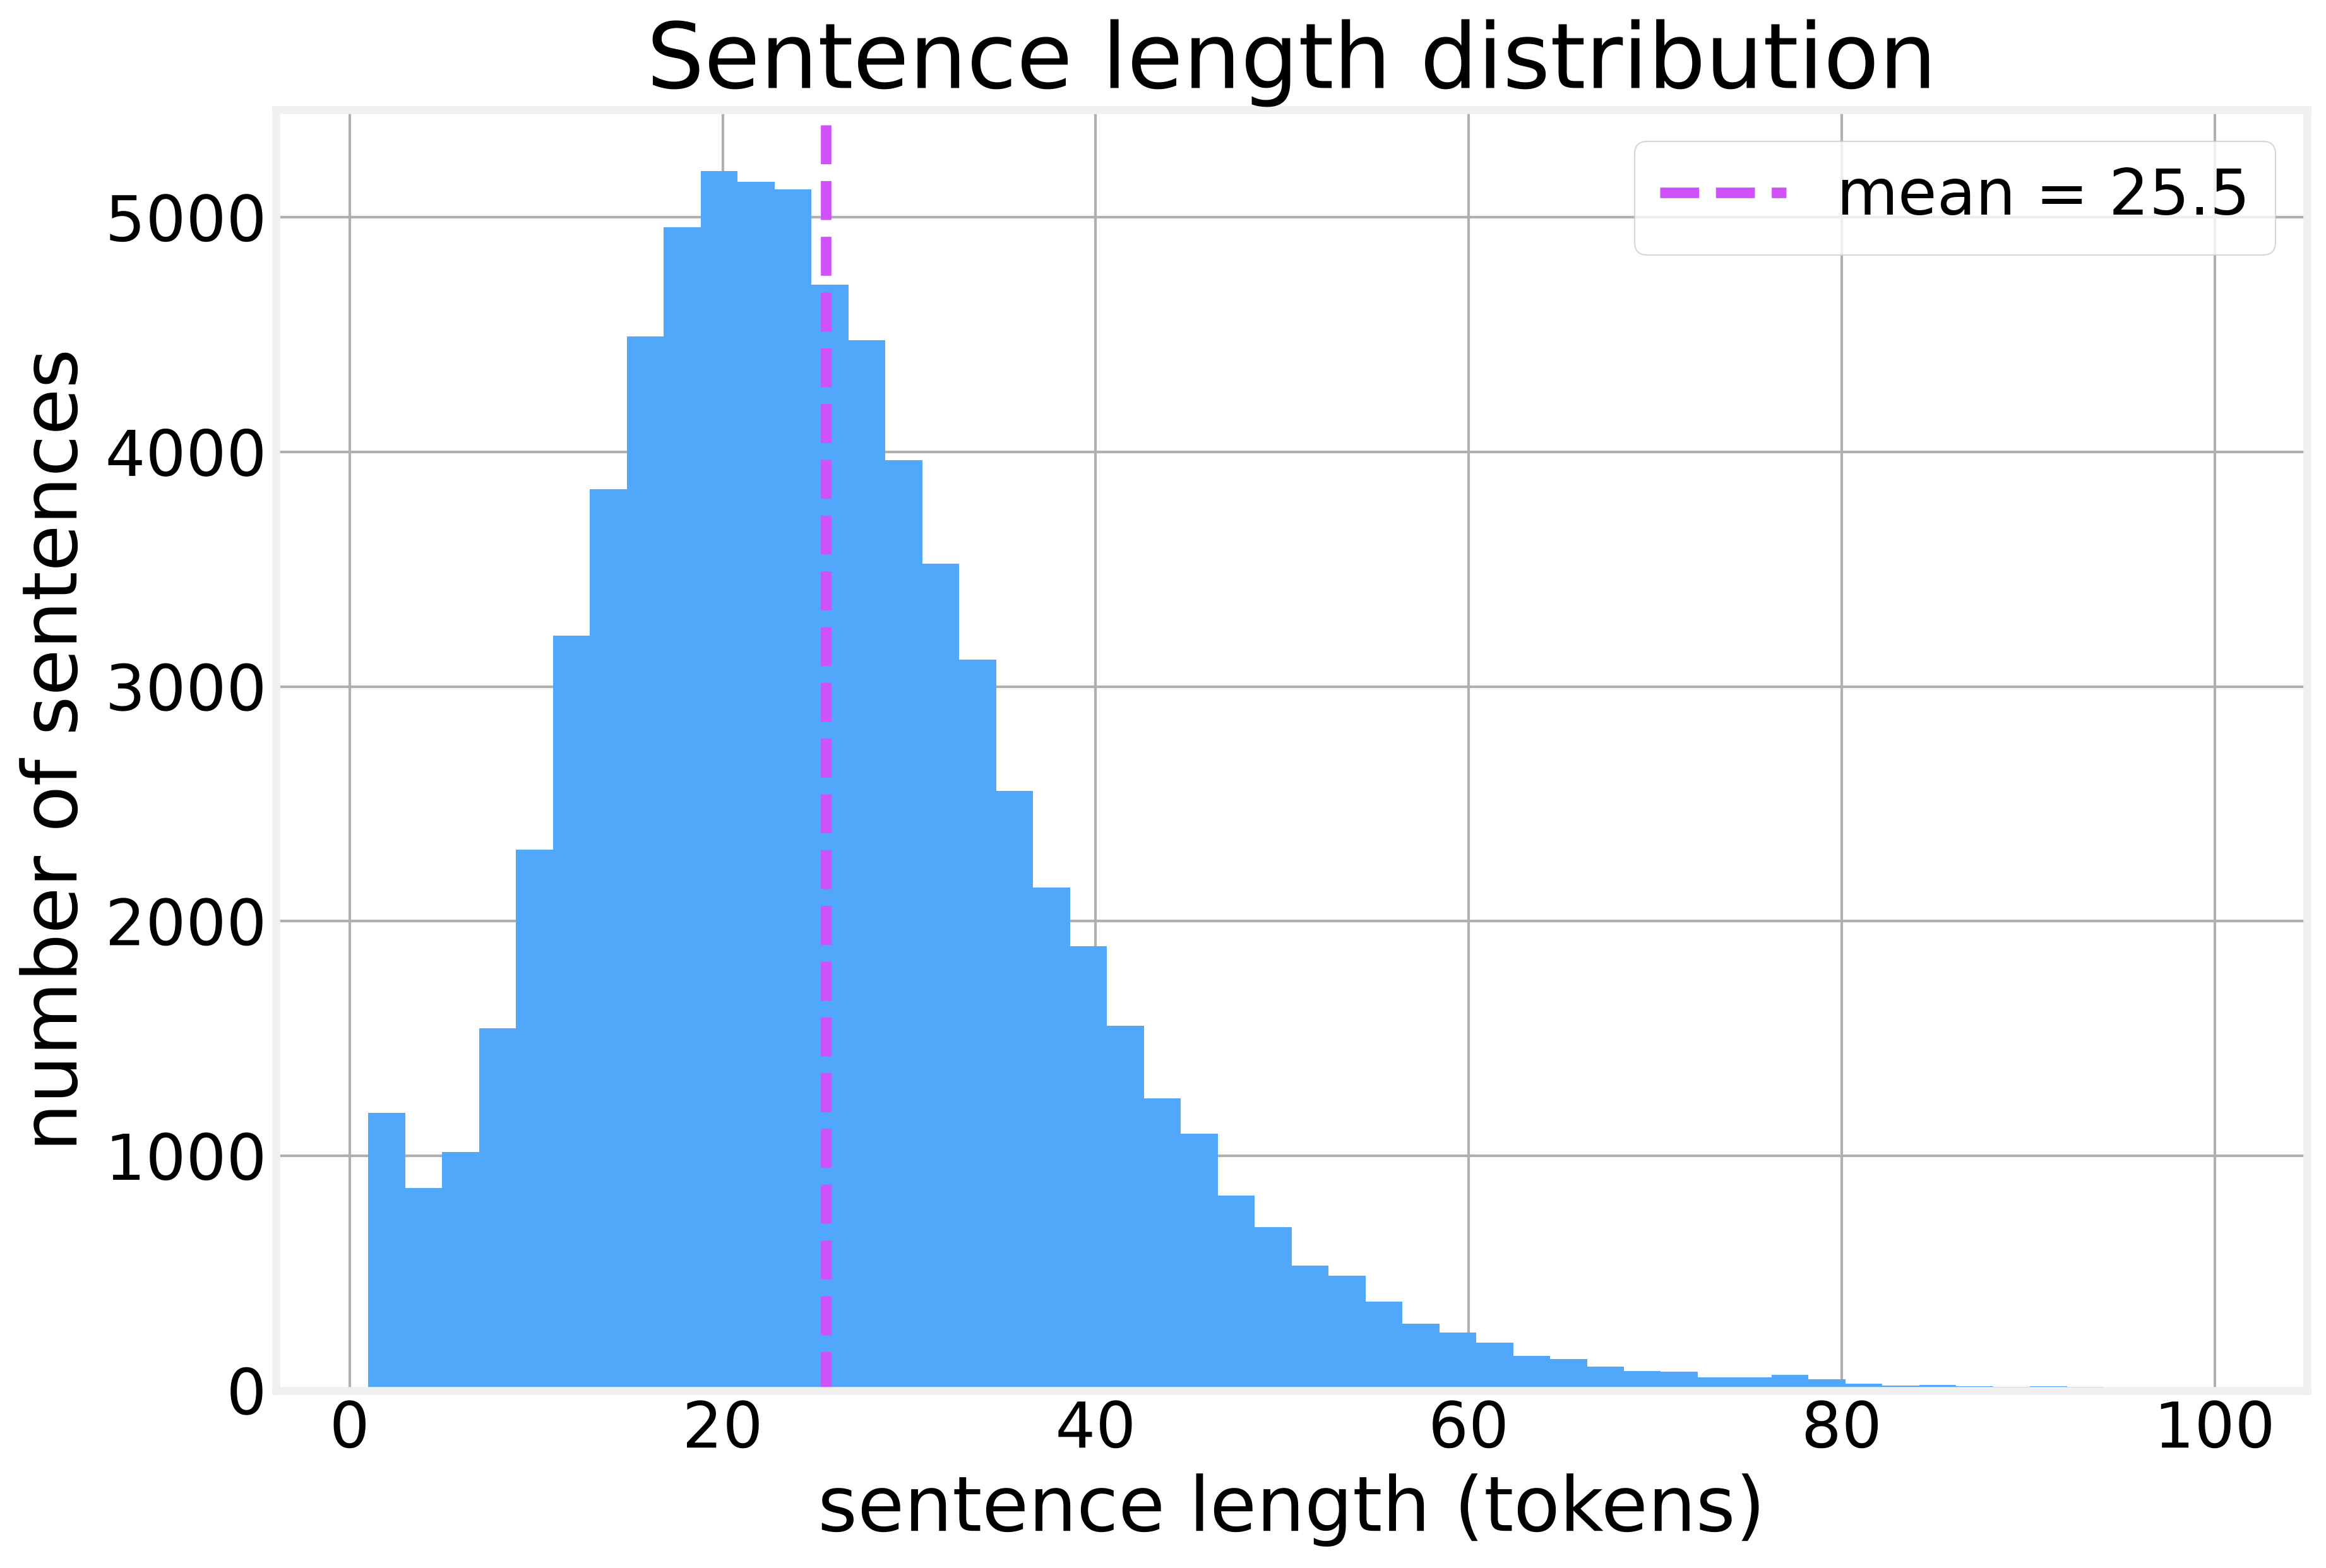

In [15]:
sent_lens = np.array([len(s.split()) for s in sentences])

print(f"sentences (sample)   : {len(sentences):,}")
print(f"tokens per sentence  : median {np.median(sent_lens):.0f} · "
      f"mean {sent_lens.mean():.1f} · p95 {np.percentile(sent_lens, 95):.0f}")

# Extrapolate the sample's sentence density to the full corpus to estimate
# how long Part 2's REBEL stage would take at ~1 sentence/second on CPU.
est_total_sentences = int(len(sentences) * len(raw_text) / len(eda_text))
est_hours = est_total_sentences / 3600
print(f"\nestimated sentences in full corpus : {est_total_sentences:,}")
print(f"estimated REBEL time on CPU        : ~{est_hours:,.1f} hours "
      f"(~1 s/sentence — use target_chars for a quick run!)")

fig, ax = plt.subplots()
ax.hist(sent_lens[sent_lens <= 100], bins=50, color=colors[0])
ax.axvline(sent_lens.mean(), color=colors[1], linestyle="--",
           label=f"mean = {sent_lens.mean():.1f}")
ax.set_xlabel("sentence length (tokens)")
ax.set_ylabel("number of sentences")
ax.set_title("Sentence length distribution")
ax.legend()
plt.tight_layout()

### Tokenization quirks to be aware of

Wikitext ships **pre-tokenized**, and two artifacts of that process will flow straight into our pipeline if we ignore them:

- **`<unk>`** — rare words were replaced by an unknown-word token when the dataset was built. Any entity containing one (e.g. a rare person name) is *unrecoverable*.
- **`@-@`, `@,@`, `@.@`** — escaped hyphens and number punctuation (`role @-@ playing` = "role-playing", `1 @,@ 000` = "1,000"). Left as-is, these end up *inside* extracted entity names.

Neither breaks the workshop — but when you see an odd node label in Part 3's graph, this is why. In production you'd normalize these before extraction.

In [16]:
for artifact in ["<unk>", "@-@", "@,@", "@.@"]:
    n = eda_text.count(artifact)
    print(f"{artifact:>6} : {n:>8,} occurrences  ({1000 * n / len(tokens):6.2f} per 1k tokens)")

example = next((s for s in sentences if "@-@" in s), None)
if example:
    print(f"\nexample: “{example[:200]}”")

 <unk> :    9,112 occurrences  (  4.83 per 1k tokens)
   @-@ :   15,719 occurrences  (  8.34 per 1k tokens)
   @,@ :    2,588 occurrences  (  1.37 per 1k tokens)
   @.@ :    2,830 occurrences  (  1.50 per 1k tokens)

example: “Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Porta”


### Vocabulary growth — Heaps' law

How fast does the vocabulary grow as we read more text? **Heaps' law** says: as a power law, $\left( V(n) \approx K \, n^\beta \right)$ with $\left( \beta \approx 0.4\text{–}0.6 \right)$ — a straight line on log-log axes that never flattens out. The practical consequence for us: **a bigger corpus slice always brings new entities**. There is no point where the graph is "done"; the corpus size we choose is a runtime/coverage trade-off, not a completeness threshold.

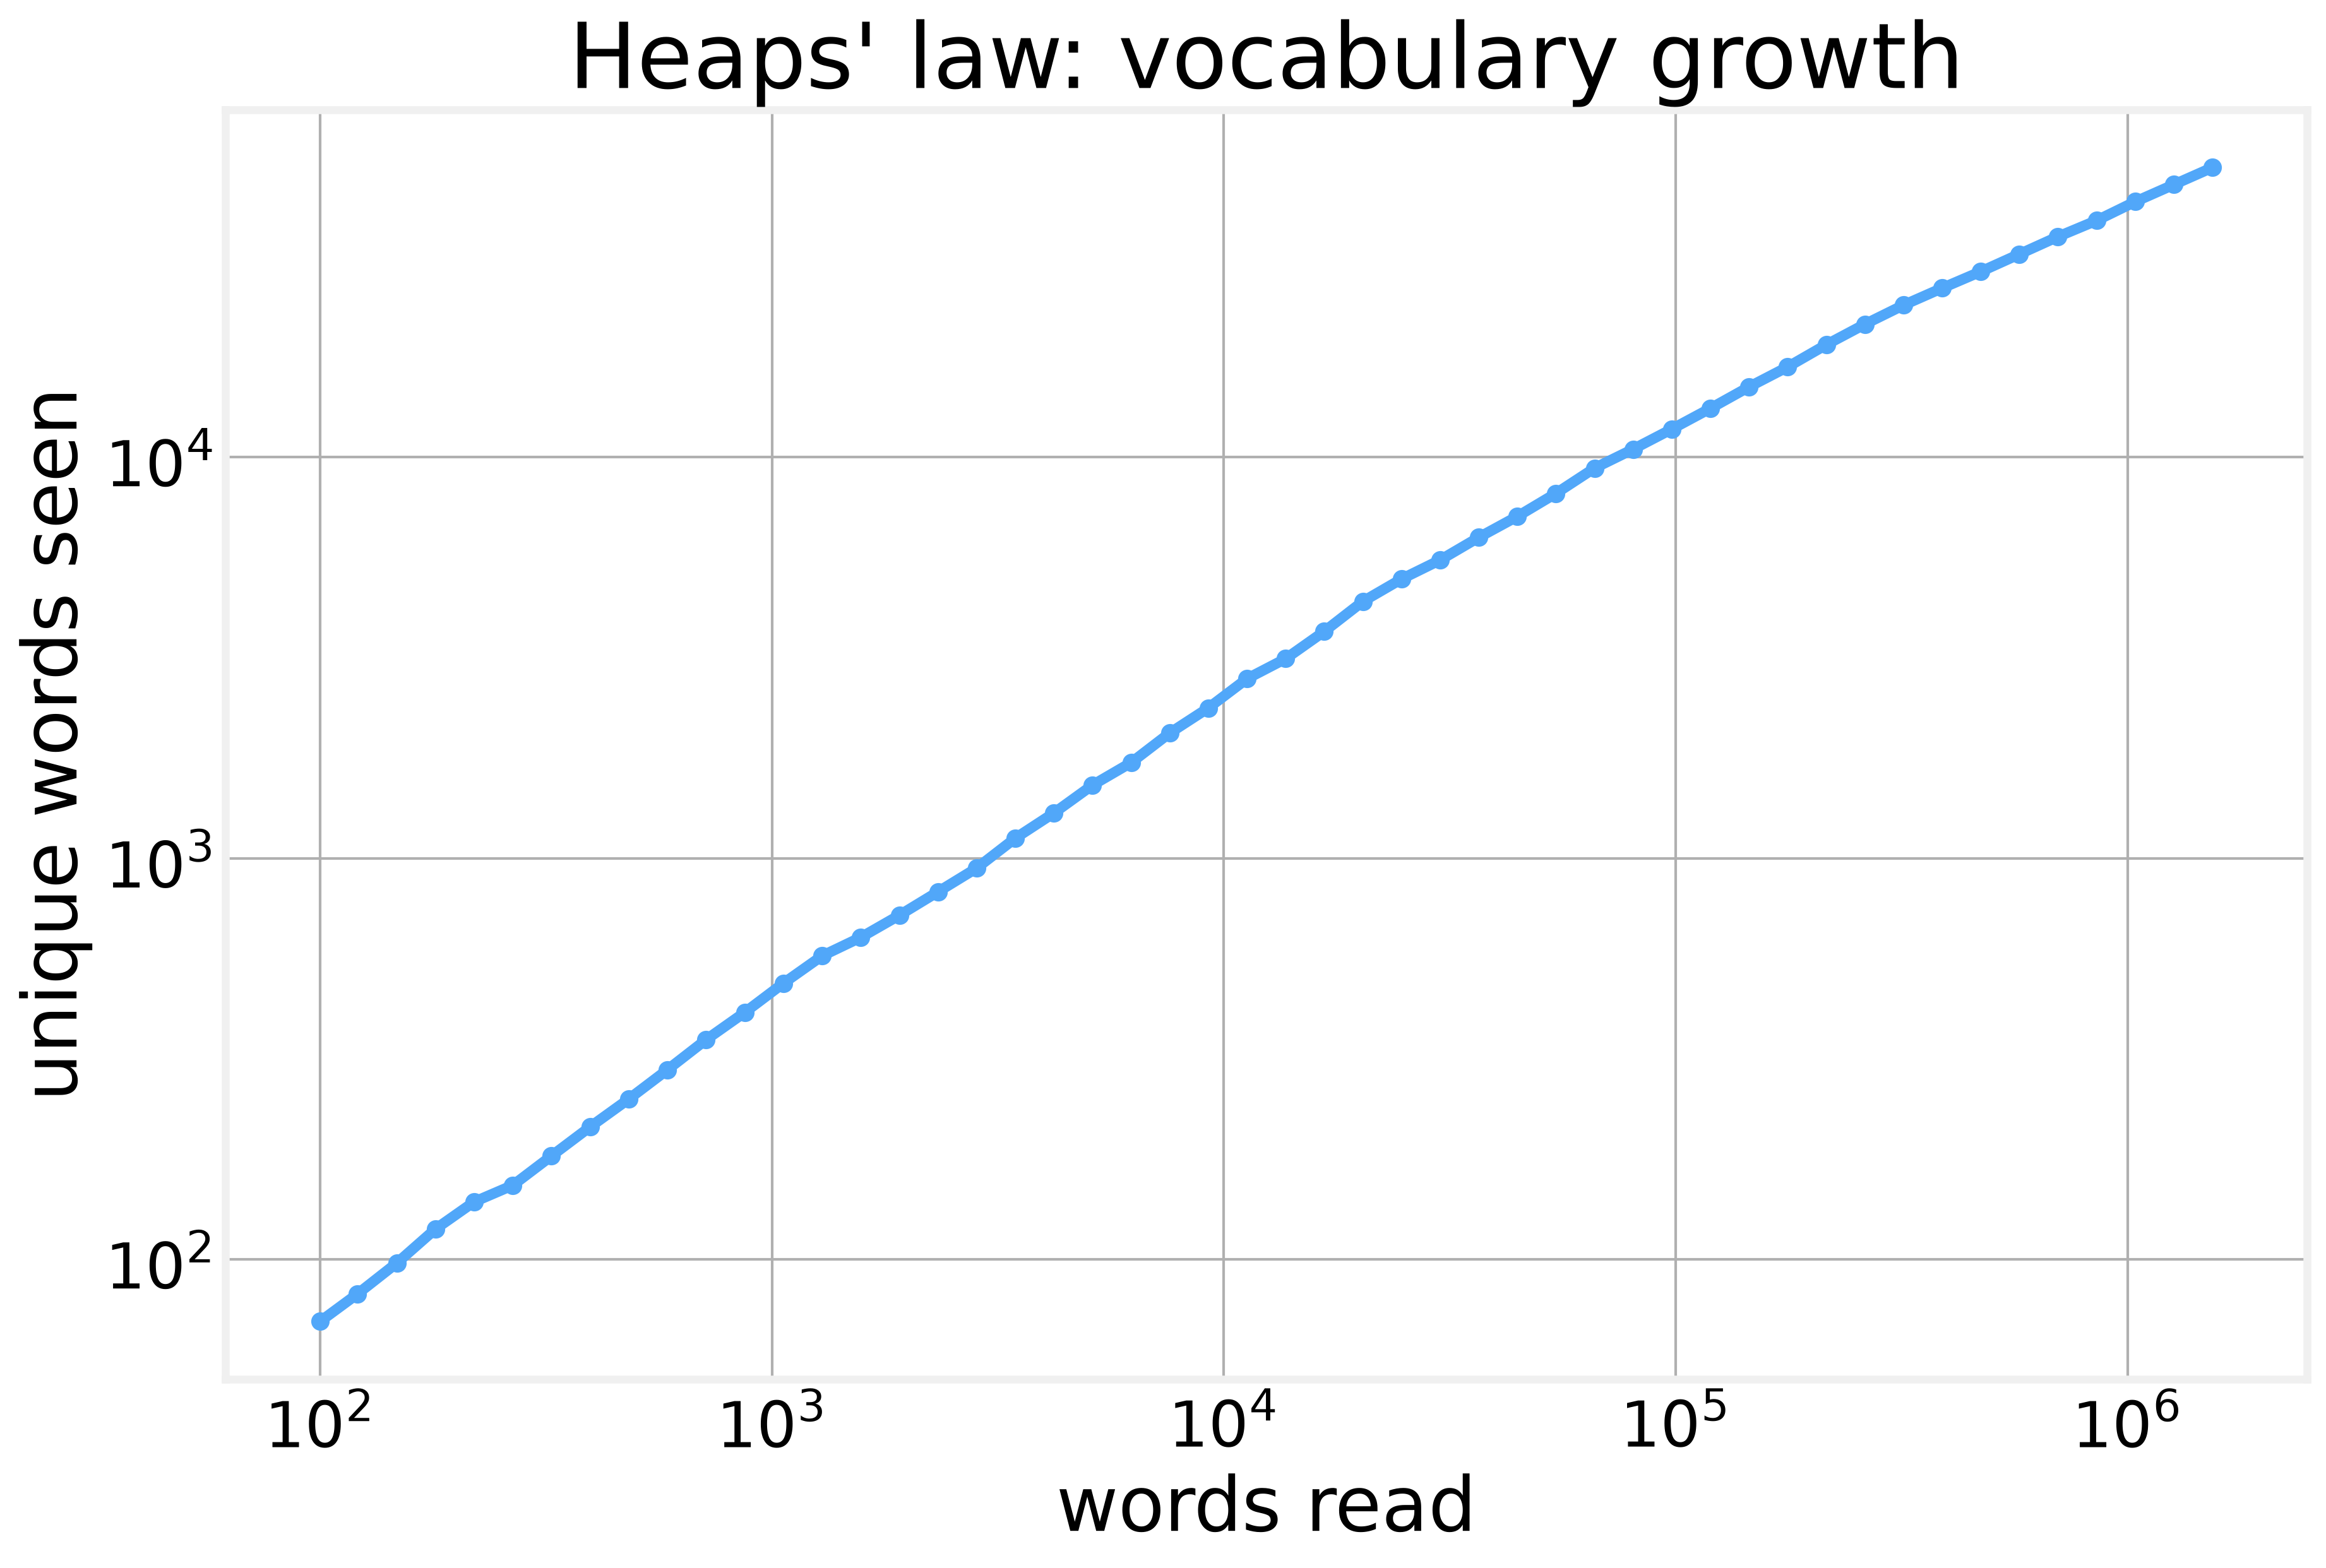

In [17]:
marks = np.unique(np.logspace(2, np.log10(len(words)), 50).astype(int))

seen, vocab_sizes, mark_idx = set(), [], 0
for i, w in enumerate(words, 1):
    seen.add(w)
    if mark_idx < len(marks) and i == marks[mark_idx]:
        vocab_sizes.append(len(seen))
        mark_idx += 1

fig, ax = plt.subplots()
ax.loglog(marks[:len(vocab_sizes)], vocab_sizes, "o-", color=colors[0])
ax.set_xlabel("words read")
ax.set_ylabel("unique words seen")
ax.set_title("Heaps' law: vocabulary growth")
plt.tight_layout()

### A crude entity preview

Part 2 will use spaCy's NER model to find entities properly. But we can get a sneak preview for free: **capitalized tokens** (that aren't stopwords) are a rough proxy for named entities in English. The most frequent ones below are the likely *hub nodes* of the knowledge graph we'll build in Part 3 — the entities with the most connections.

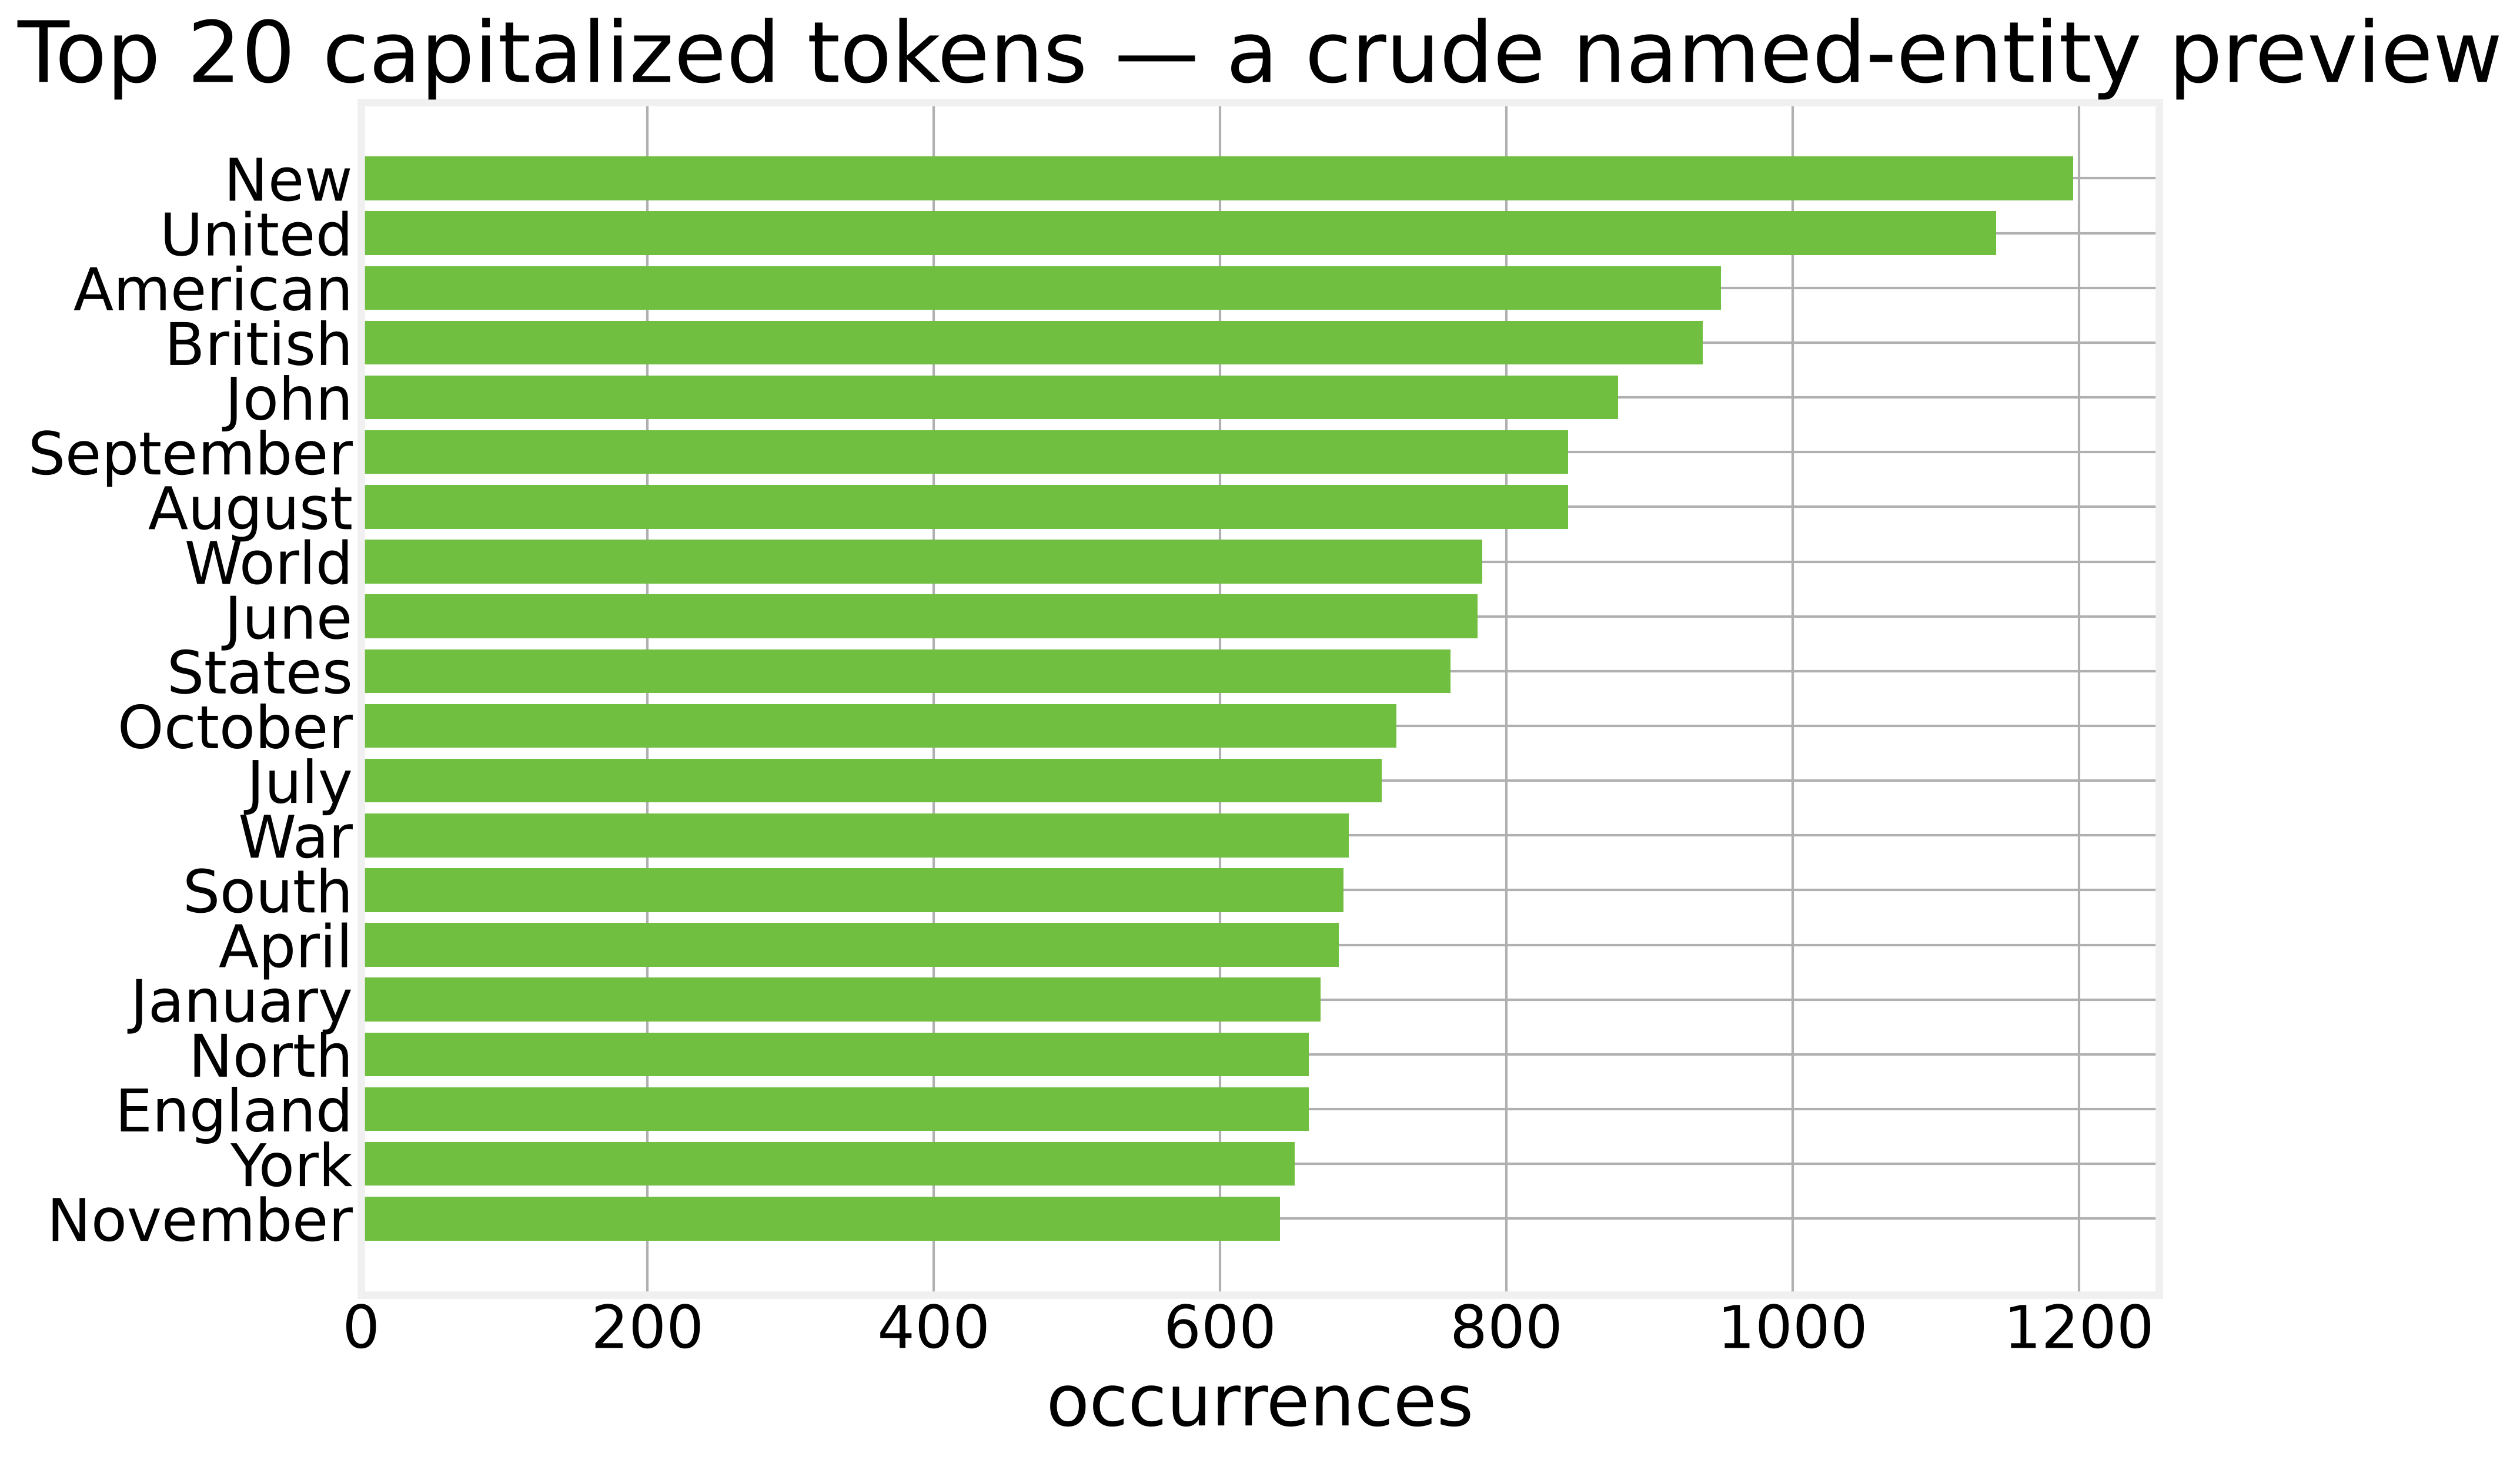

In [18]:
cap_freq = Counter(
    t for t in tokens
    if t.istitle() and len(t) > 2 and t.lower() not in ENGLISH_STOP_WORDS
)
top_caps = cap_freq.most_common(20)

labels, counts = zip(*top_caps)
fig, ax = plt.subplots()
ax.barh(range(len(labels)), counts, color=colors[2])
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("occurrences")
ax.set_title("Top 20 capitalized tokens — a crude named-entity preview")
plt.tight_layout()

In [19]:
# --- CHECKPOINT OUT: corpus.txt --------------------------------------------------
# This is Part 2's input. From here on, the pipeline never touches the loader
# again — the corpus is frozen on disk, which also makes your runs reproducible.
save_text("corpus.txt", raw_text)

[checkpoint] saved  checkpoints/corpus.txt  (526,514,281 chars)


<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>